# Python EDA
Moving over to Python to make some interactive charts maybe

In [1]:
import geopandas as gpd
states_shape = gpd.read_file("../data/cleandata/states_shifted.shp")

In [2]:
#simplifying, getting rid of extra columns
states_shape = states_shape[['name', 'postal', 'latitude','longitude','geometry']]


In [49]:
import pandas as pd
norc_2024 = pd.read_csv('../data/rawdata/AP_NORC_survey.csv')

In [4]:
norc_2024[["state_abbr", "state_name"]] = norc_2024["P_STATE"].str.extract(r"\((.*?)\)\s*(.*)")

In [5]:
short_norc = norc_2024[['SU_ID', 'LIKELYVOTER', 'RACE0_VOTE','RACE0_PARTY','GENDER','TRACK','FORCAND','ABORTION',
'GUNPOLICY', 'VOTEFRAUD','FRACKING','FTVOTER','EDUC','INCOME','PARTYFULL','MARRIED',
'AGE65','RELIG4','ATTENDANCE','TIKTOKUSER','LGBT','state_abbr']]

#removing non-voters
short_norc = short_norc[short_norc["LIKELYVOTER"] != '(2) Nonvoter']
short_norc = short_norc[short_norc["AGE65"] != "(99) DON'T KNOW/SKIPPED ON WEB/REFUSED (VOL)"]

### Age, political party, and gender bar chart
This will likely be used in conjunction with a map of the state

In [6]:
short_norc ['GENDER'] = short_norc['GENDER'].replace({'(2) Women': 'Female', '(1) Men': 'Male', '(3) Nonbinary/Some other way' : 'Other', "(99) DON'T KNOW/SKIPPED ON WEB/REFUSED (VOL)" : 'Other'})

short_norc ['RACE0_VOTE'] = short_norc['RACE0_VOTE'].replace({'(8639) Donald Trump': 'Donald Trump', '(64984) Kamala Harris': 'Kamala Harris', '(100008) Another candidate' : 'Other', '(69459) Chase Oliver' : 'Other', ' ' : 'Other', '(895) Jill Stein' : 'Other', '(71841) Robert Kennedy' : 'Other','(71845) Cornel West' : 'Other', '(100013) None of These Candidates' : 'Other'})

In [7]:
total_voters = (
    short_norc.groupby(["AGE65","RACE0_VOTE"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

male_voters = (
    short_norc[short_norc["GENDER"]=="Male"]
    .groupby(["AGE65","RACE0_VOTE"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

female_voters = (
    short_norc[short_norc["GENDER"]=="Female"]
    .groupby(["AGE65","RACE0_VOTE"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

In [8]:
import plotly.graph_objects as go

fig = go.Figure()

#colors
trump_color = "#E9141D"
harris_color = "#0015BC" 
other_color = '#B0B0B0'

# TOTAL
fig.add_bar(x=total_voters.AGE65, y=total_voters["Donald Trump"], name="Donald Trump", visible=True, marker_color=trump_color)
fig.add_bar(x=total_voters.AGE65, y=total_voters["Kamala Harris"], name="Kamala Harris", visible=True, marker_color=harris_color)
fig.add_bar(x=total_voters.AGE65, y=total_voters["Other"], name="Other", visible=True, marker_color=other_color)

# MALE
fig.add_bar(x=male_voters.AGE65, y=male_voters["Donald Trump"], name="Donald Trump", visible=False, marker_color=trump_color)
fig.add_bar(x=male_voters.AGE65, y=male_voters["Kamala Harris"], name="Kamala Harris", visible=False, marker_color=harris_color)
fig.add_bar(x=male_voters.AGE65, y=male_voters["Other"], name="Other", visible=False, marker_color=other_color)

# FEMALE
fig.add_bar(x=female_voters.AGE65, y=female_voters["Donald Trump"], name="Donald Trump", visible=False, marker_color=trump_color)
fig.add_bar(x=female_voters.AGE65, y=female_voters["Kamala Harris"], name="Kamala Harris", visible=False, marker_color=harris_color)
fig.add_bar(x=female_voters.AGE65, y=female_voters["Other"], name="Other", visible=False, marker_color=other_color)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label="Total",
                    method="update",
                    
                    args=[{"visible":[True,True,True,False,False,False,False,False,False]}, {"title":"2024 Vote by Age Group (All Voters)"}]
                ),
                dict(
                    label="Male",
                    method="update",
                    args=[{"visible":[False,False,False,True,True,True,False,False,False]}, {"title":"2024 Vote by Age Group (Male Voters)"}]
                ),
                dict(
                    label="Female",
                    method="update",
                    args=[{"visible":[False,False,False,False,False,False,True,True,True]}, {"title":"2024 Vote by Age Group (Female Voters)"}]
                )
            ],
            direction="down"
        )
    ],
    barmode="group",
    xaxis_title="Age Group",
    yaxis_title="Number of Voters"
)

fig.update_layout(
    title="2024 Vote by Age Group (All Voters)"
)

fig.update_layout(
    yaxis=dict(range=[0, 20000])
)

fig.show()

### Political party leaning and gender over time

In [1]:
import pandas as pd
# getting all the npors in
npors_2020 = pd.read_csv('../data/cleandata/NPORS_2020_clean.csv')
npors_2021 = pd.read_csv('../data/cleandata/NPORS_2021_clean.csv')
npors_2022 = pd.read_csv('../data/cleandata/NPORS_2022_clean.csv')
npors_2023 = pd.read_csv('../data/cleandata/NPORS_2023_clean.csv')
npors_2024 = pd.read_csv('../data/cleandata/NPORS_2024_clean.csv')
npors_2025 = pd.read_csv('../data/cleandata/NPORS_2025_clean.csv')

In [2]:
party_2020 = npors_2020[['PARTY_AP20', 'AGE_AP20', 'SEXASK_AP20']].copy() #no gender question
party_2021 = npors_2021[['PARTY_AP21', 'AGE_AP21', 'GENDER_AP21']].copy()
party_2022 = npors_2022[['PARTY', 'AGE', 'GENDER']].copy()
party_2023 = npors_2023[['PARTY', 'AGE', 'GENDER']].copy()
party_2024 = npors_2024[['PARTY', 'AGECAT', 'GENDER']].copy() #no description for agecat
party_2025 = npors_2025[['PARTY','AGECAT', 'GENDER']].copy()


In [3]:
#cleaning ages
#AGECAT = 18-29, 30-49, 50-64, and 64+, plus refused/blank in 2025
import numpy as np

#2020 is a string
party_2020['AGECAT'] = party_2020['AGE_AP20'].replace('Refused', 99)
party_2020['AGECAT'] = pd.to_numeric(party_2020['AGECAT'])

#2021-2023 have numeric formats, now 2020 does as well
bins = [17, 29, 49, 64, 98, np.inf]
labels = ['18-29', '30-49', '50-64', '65+', 'Refused']

party_2020['AGECAT'] = pd.cut(party_2020['AGECAT'], bins=bins, labels=labels)
party_2021['AGECAT'] = pd.cut(party_2021['AGE_AP21'], bins=bins, labels=labels)
party_2022['AGECAT'] = pd.cut(party_2022['AGE'], bins=bins, labels=labels)
party_2023['AGECAT'] = pd.cut(party_2023['AGE'], bins=bins, labels=labels)


#2024 only has numbers
age_map = {
    1: "18-29",
    2: "30-49",
    3: "50-64",
    4: "65+",
    99: "Refused/Blank"
}

party_2024['AGECAT'] = party_2024['AGECAT'].map(age_map)


In [4]:
#cleaning genders, covering all possiblities in the 6 datasets
gender_map = {
    'A man': "Male",
    'A woman': "Female",
    'In some other way': "Other",
    'Refused /  Web blank': "Refused/Blank",
    'Refused/Web blank': "Refused/Blank",
    'Refused': "Refused/Blank",
    'Woman': "Female",
    'Female': "Female",
    'Male': "Male",
    'Man': "Male"
}
party_2020['IDENTITY'] = party_2020['SEXASK_AP20'].map(gender_map)
party_2021['IDENTITY'] = party_2021['GENDER_AP21'].map(gender_map)
party_2022['IDENTITY'] = party_2022['GENDER'].map(gender_map)
party_2023['IDENTITY'] = party_2023['GENDER'].map(gender_map)
party_2024['IDENTITY'] = party_2024['GENDER'].map(gender_map)
party_2025['IDENTITY'] = party_2025['GENDER'].map(gender_map)

In [5]:
#all of the party labels are consistent, so let's combine this into one large dataset
party_2020 = party_2020.rename(columns={'PARTY_AP20': 'PARTY'})
party_2020 = party_2020.drop(columns=['AGE_AP20', 'SEXASK_AP20'])

party_2021 = party_2021.rename(columns={'PARTY_AP21': 'PARTY'})
party_2021 = party_2021.drop(columns=['AGE_AP21', 'GENDER_AP21'])

party_2022 = party_2022.drop(columns=['AGE', 'GENDER'])
party_2023 = party_2023.drop(columns=['AGE','GENDER'])
party_2024 = party_2024.drop(columns=['GENDER'])
party_2025 = party_2025.drop(columns=['GENDER'])


party_2020['YEAR'] = 2020
party_2021['YEAR'] = 2021
party_2022['YEAR'] = 2022
party_2023['YEAR'] = 2023
party_2024['YEAR'] = 2024
party_2025['YEAR'] = 2025

In [6]:
df_list = [party_2020, party_2021, party_2022, party_2023, party_2024, party_2025]
all_party = pd.concat(df_list, axis=0, ignore_index=True)


#some final cleanup
all_party['PARTY'] = all_party['PARTY'].replace('Refused /  Web blank', 'Refused')
all_party['PARTY'] = all_party['PARTY'].replace('Refused/Web blank', 'Refused')
all_party['PARTY'] = all_party['PARTY'].replace('Something else', 'Other')
all_party['AGECAT'] = all_party['AGECAT'].replace('Refused/Blank', 'Refused')
all_party['IDENTITY'] = all_party['IDENTITY'].replace('Refused/Blank', 'Refused')

In [58]:
#saving
all_party.to_csv('../data/cleandata/age_gender_party.csv', index=False)

In [7]:

#making the chart
counts = (
    all_party.groupby(['YEAR', 'IDENTITY', 'PARTY', 'AGECAT'])
      .size()
      .reset_index(name='count')
)

counts['year_total'] = counts.groupby('YEAR')['count'].transform('sum')
counts['prop_year'] = counts['count'] / counts['year_total']

#only male and female
plot_data = counts[~counts['IDENTITY'].isin(['Refused', 'Other'])]
plot_data = plot_data[~plot_data['PARTY'].isin(['Refused', 'Other'])]
plot_data = plot_data[~plot_data['AGECAT'].isin(['Refused'])]

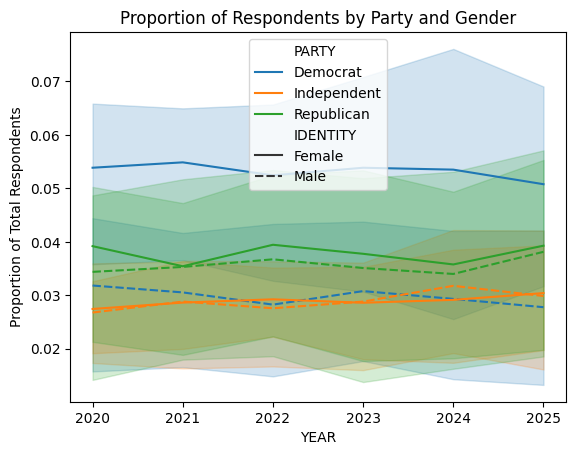

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=plot_data,
    x='YEAR',
    y='prop_year',
    hue='PARTY',
    style='IDENTITY'
)

plt.title("Proportion of Respondents by Party and Gender")
plt.ylabel("Proportion of Total Respondents")
plt.show()

In [67]:
import altair as alt

#selection for age groups
age_dropdown = alt.binding_select(
    options=sorted(plot_data['AGECAT'].unique()), 
    name='Age Category:'
)
age_select = alt.selection_single(
    fields=['AGECAT'], 
    bind=age_dropdown, 
    init={'AGECAT': sorted(plot_data['AGECAT'].unique())[0]}
)

#legend select for party
party_select = alt.selection_multi(
    fields=['PARTY'],
    bind='legend', 
    name='Show Parties:'
)


In [78]:
line = (
    alt.Chart(plot_data)
    .mark_line()
    .encode(
        x=alt.X('YEAR:O', title='Year'),
        y=alt.Y(
            'prop_year:Q', 
            title='Proportion of Respondents', 
            scale=alt.Scale(domain=[0,0.09]),
            axis=alt.Axis(format='%')
        ),
        color='PARTY:N',
        strokeDash='IDENTITY:N'
    )

)

points = (
    alt.Chart(plot_data)
    .mark_point(size=50,
        color='white', 
        stroke='grey', 
        strokeWidth=1.5,
        opacity=0.3)
    .encode(
        x='YEAR:O',
        y='prop_year:Q',
        tooltip=[
            'YEAR',
            'PARTY',
            'IDENTITY',
            alt.Tooltip('prop_year:Q', title='% of Respondants', format='.1%')
        ]
    )
)

chart = (
    (line + points)
    .add_selection(age_select, party_select)
    .transform_filter(age_select)
    .encode(
        opacity=alt.condition(party_select, alt.value(1), alt.value(0))
    )
    .properties(width=700, height=200, title="Percent of Respondents by Party, Gender, and Age Over Time")
)

In [79]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
chart

alt.LayerChart(...)